# Curriculum Elements × Learning Outcomes — consistency, chance level, correlations

**Status:** `validation_required`. Companion analysis to `Buildbot_AI_literacy_analysis.ipynb`, built 2026-09-15.

**Research questions**
1. How far above *chance level* (25% for 4-option multiple choice) is performance, per item and per child?
2. Are there children who answer **consistently** correctly (vs. high variability / confusion)?
3. Do outcomes correlate with **curriculum elements** (theme, mastery role, week taught, timing mismatch, revisiting)?

**Key data decisions (differ from `Buildbot_AI_literacy_analysis.ipynb`):**
- Knowledge items in the combined file are **already scored 0/1** except `LLMdesign_1` (raw option numbers 1–4 + 5). **`99` = explicit "I don't know".** Accuracy uses answered items (0/1) only; IDK is analyzed in §3b. Empty/`NaN` = truly missing. (The earlier notebook replaced 99/NaN with 0, counting IDK as failures.)
- **`LLMdesign_1` recode (explicit, reversible):** codebook correct answer is option **c** ("Tell me about science" = vague prompt). Combined file stores 1–5. Mapping used here: 3→correct, {1,2,4}→wrong, **5→IDK** (5 is the modal value and rises T1→T7, consistent with IDK; codebook does not document 5 — flag for author check). Do not confuse with the earlier notebook's recode that zeroed an already-scored column.

**Inputs**
- `Data/combineddf_T1_T4_T7/combined_df-Table 1.csv` (experimental + control; T1/T4/T7)
- `Data/BuildBots_engagement_children_cntrl&exp_merged_T1-T7_EN.csv` (weekly IMI T1–T7)
- `curriculum_concepts__validation_required.csv` (52 enacted concepts: theme, mastery, week)
- `concept_item_mapping__validation_required.csv` (concept↔item links, evidence-based)
- `survey_items_inventory__validation_required.csv` (item metadata incl. intended week)

**Nothing is hardcoded:** every number below is computed at runtime.

## 1. Setup & data loading

Chance level is a parameter (0.25 for 4-option MC). Item ids are normalized (text after `:` stripped; `AI_` prefix removed) so they join with the validated mapping/inventory tables.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

CHANCE = 0.25          # 4-option multiple choice
ALPHA = 0.05           # significance level for chance-level tests

BASE = Path('.')
df = pd.read_csv(BASE / 'Data/combineddf_T1_T4_T7/combined_df-Table 1.csv', sep=';')
df = df[df['Experimental_group'].isin(['experimental', 'control'])].copy()
df['Participant ID'] = pd.to_numeric(df['Participant ID'], errors='coerce')

def norm_id(col):
    cid = col.split(':')[0].strip()
    return cid[3:] if cid.startswith('AI_') else cid

ITEM_RE = re.compile(r'^(robotparts|sensors|microcontrollers|LLMdesign)_\d+$|^PR\d+$|^[A-Z]{2}\d{2}$')
item_cols = [c for c in df.columns if ITEM_RE.match(norm_id(c))]
id_map = {c: norm_id(c) for c in item_cols}
df = df.rename(columns=id_map)
item_ids = list(dict.fromkeys(id_map.values()))  # DA09 from AI_DA09

IDK = 99.0
ANSWERED = {0.0, 1.0}
for c in item_ids:
    df[c] = pd.to_numeric(df[c], errors='coerce').replace(999, np.nan)

# LLMdesign_1: codebook MCQ, correct = option c = 3; 5 treated as IDK (see header)
if 'LLMdesign_1' in df.columns:
    raw = pd.to_numeric(df['LLMdesign_1'], errors='coerce')
    rec = np.where(raw == 5, IDK, np.where(raw == 3, 1.0, np.where(raw.isin([1, 2, 4]), 0.0, np.nan)))
    df['LLMdesign_1'] = rec
    print('LLMdesign_1 recoded: 3->1, {1,2,4}->0, 5->99 (IDK assumption)')

bad = {c: sorted(pd.Series(df[c]).dropna().unique()) for c in item_ids
       if not set(pd.Series(df[c]).dropna().unique()).issubset({0.0, 1.0, IDK})}
print(f'{len(item_ids)} knowledge items; unexpected values: {bad if bad else "none"}')
if bad:
    item_ids = [c for c in item_ids if c not in bad]
    print('Still excluded:', list(bad))
print('Rows per wave:', df['Timepoint'].value_counts().to_dict())
print('Participants:', df['Participant ID'].nunique())
print('Groups:', df.groupby('Experimental_group')['Participant ID'].nunique().to_dict())
print(df.groupby(['Experimental_group', 'Timepoint']).size().unstack())

WAVES = [w for w in ['T1', 'T4', 'T7'] if w in set(df['Timepoint'])]
GROUPS = [g for g in ['experimental', 'control'] if g in set(df['Experimental_group'])]

LLMdesign_1 recoded: 3->1, {1,2,4}->0, 5->99 (IDK assumption)
23 knowledge items; unexpected values: none
Rows per wave: {'T1': 58, 'T7': 55, 'T4': 51}
Participants: 63
Groups: {'control': 32, 'experimental': 31}
Timepoint           T1  T4  T7
Experimental_group            
control             28  22  26
experimental        30  29  29


## 2. Item × wave accuracy vs. chance

Per item and wave: proportion correct (over *answered* items only), Wilson 95% CI, and a one-sided binomial test against chance (H1: above chance). An item whose CI lies entirely **below** chance at T7 suggests a systematic distractor ('worse than guessing').

*Output: [will show when run]*

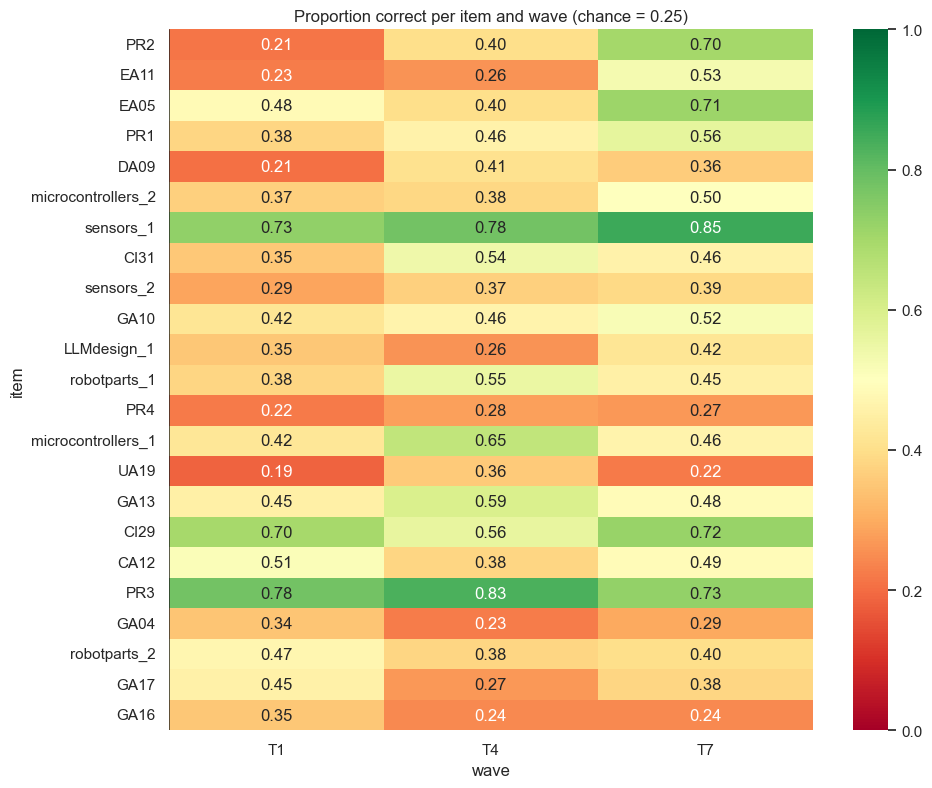

T7 items significantly ABOVE chance: 17 / 23
T7 items at/below chance (point estimate): ['GA16', 'UA19']
T7 items with CI entirely BELOW chance (systematic distractor?): []


In [2]:
def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    d = 1 + z**2 / n
    c = p + z**2 / (2 * n)
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))
    return ((c - m) / d, (c + m) / d)

rows = []
for item in item_ids:
    for w in WAVES:
        raw = df.loc[df['Timepoint'] == w, item]
        s = raw[raw.isin(ANSWERED)].dropna()   # answered items only (0/1); IDK excluded
        n, k = len(s), int(s.sum())
        lo, hi = wilson(k, n)
        p_above = stats.binomtest(k, n, CHANCE, alternative='greater').pvalue if n else np.nan
        n_valid = raw.notna().sum()
        rows.append(dict(item=item, wave=w, n=n, k=k, acc=k / n if n else np.nan,
                         ci_lo=lo, ci_hi=hi, p_above_chance=p_above,
                         n_idk=int((raw == IDK).sum()),
                         idk_rate=(raw == IDK).sum() / n_valid if n_valid else np.nan))
acc = pd.DataFrame(rows)

wide = acc.pivot(index='item', columns='wave', values='acc')[WAVES]
wide['gain_T7_T1'] = wide['T7'] - wide['T1']
wide = wide.sort_values('gain_T7_T1', ascending=False)

plt.figure(figsize=(10, max(6, len(wide) * 0.35)))
sns.heatmap(wide[WAVES], annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1)
plt.axvline(0, color='k', lw=0.5)
plt.title(f'Proportion correct per item and wave (chance = {CHANCE})')
plt.tight_layout(); plt.show()

below = acc[(acc.wave == 'T7') & (acc.ci_hi < CHANCE)]
at_or_below = acc[(acc.wave == 'T7') & (acc.acc <= CHANCE)]
print(f'T7 items significantly ABOVE chance: '
      f"{((acc.wave == 'T7') & (acc.p_above_chance < ALPHA)).sum()} / {(acc.wave == 'T7').sum()}")
print('T7 items at/below chance (point estimate):', sorted(at_or_below.item.tolist()))
print('T7 items with CI entirely BELOW chance (systematic distractor?):', sorted(below.item.tolist()))

## 3. Per-child consistency: who actually learned?

Aggregate scores can hide that no individual child learned reliably. For each child:
- total correct / total answered (pooled across waves), with a one-sided binomial test vs. chance;
- per-wave accuracy trajectory;
- per-item **transition pattern** across waves (`0→1→1` = learned & retained, `1→1→0` = lost, `0→1→0` = unstable, `1→0→1` = unstable, `0→0→0` = never, `1→1→1` = stable mastery).

'Consistent learner' = child whose pooled accuracy is significantly above chance (binomial, one-sided).

*Output: [will show when run]*

Children significantly above chance (pooled, binomial p<0.05): 40 / 63
(Note: with 63 tests, expect ~ 3.2 false positives under pure chance.)


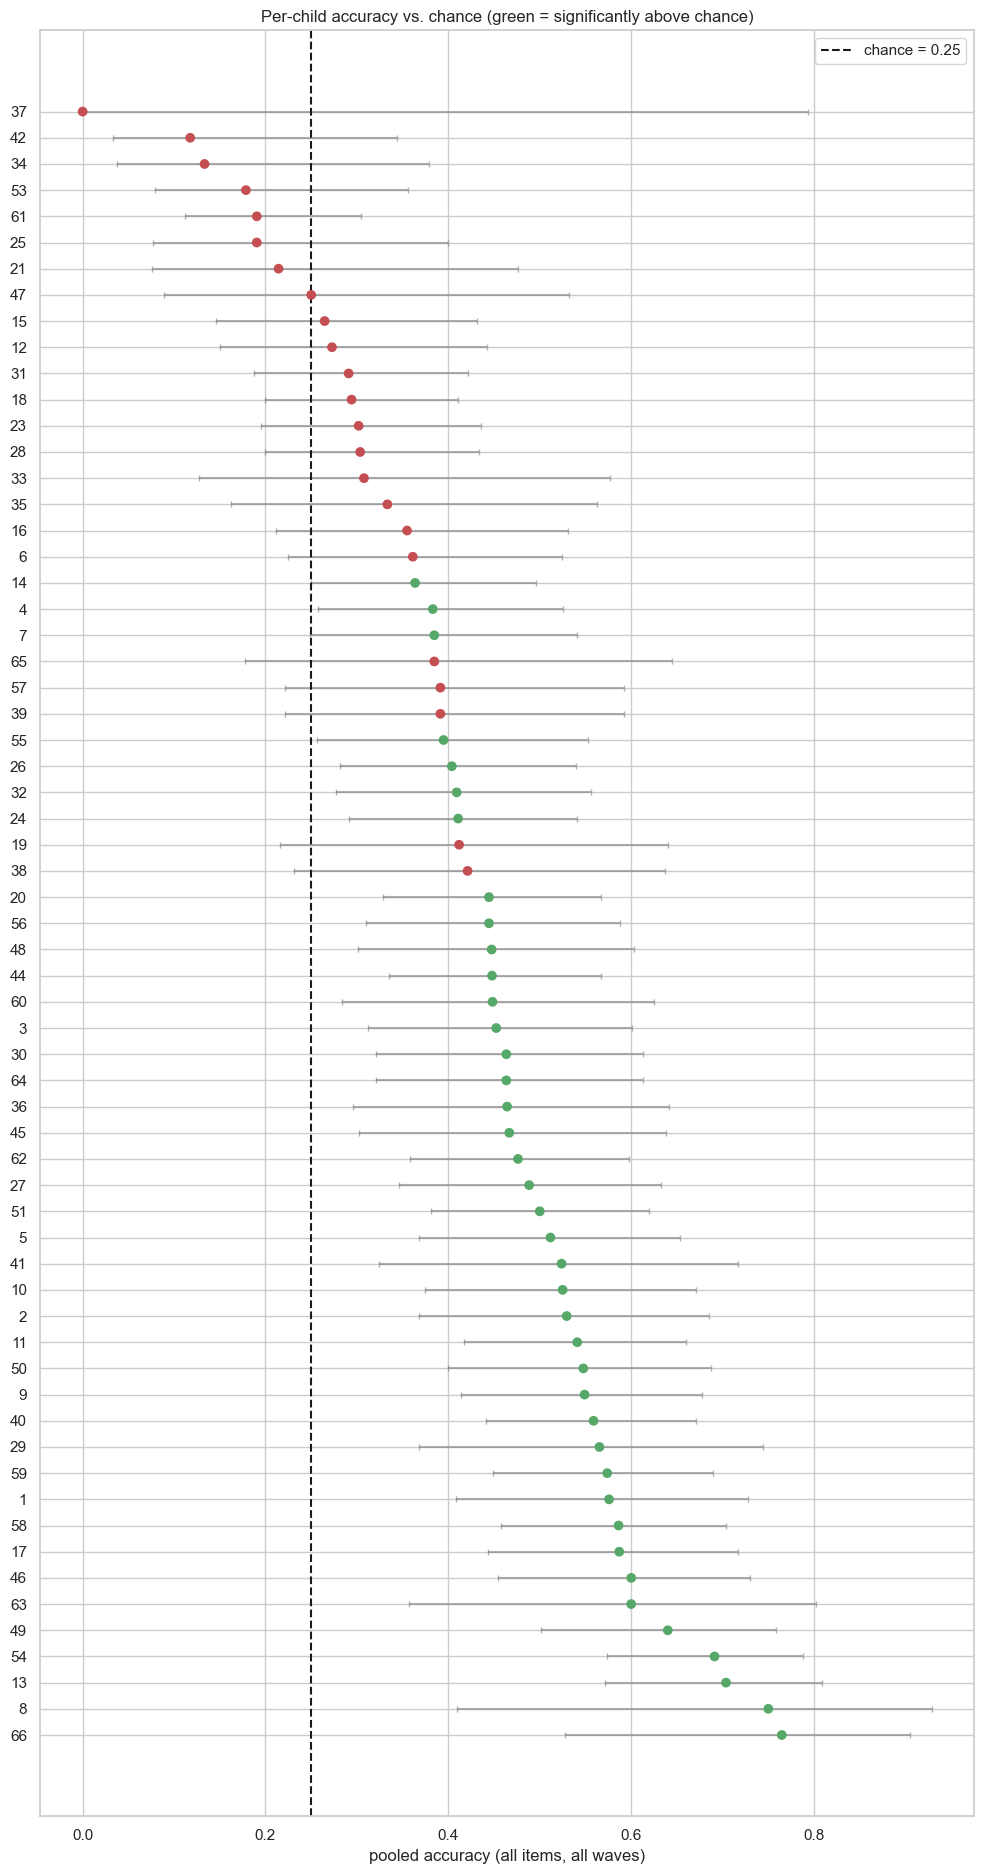


Transition-pattern counts (child × item, fully answered only):
9→9→9    120
1→1→1     97
0→0→0     94
9→0→0     55
0→0→1     43
9→9→0     42
0→1→1     40
1→0→0     39
0→9→9     39
9→1→1     36
0→1→0     35
9→0→9     34
9→0→1     33
9→9→1     28
1→0→1     27
0→0→9     26
1→1→0     26
0→9→0     25
9→1→0     20
9→1→9     17
1→9→9     16
1→9→0     13
1→9→1     12
0→9→1     10
0→1→9      8
1→1→9      8
1→0→9      5

Patterns ending correct: 110; patterns with final-wave loss: 92


In [3]:
kids = []
for pid, g in df.groupby('Participant ID'):
    vals = g[item_ids].values.ravel()
    vals = vals[np.isin(vals, [0.0, 1.0])]  # answered only; IDK excluded from accuracy
    n, k = len(vals), int(np.nansum(vals))
    p = stats.binomtest(k, n, CHANCE, alternative='greater').pvalue if n else np.nan
    def _masked_mean(sub):
        v = sub[item_ids].values.astype(float).ravel()
        v = v[np.isin(v, [0.0, 1.0])]
        return v.mean() if len(v) else np.nan
    per_wave = {w: _masked_mean(g[g['Timepoint'] == w]) for w in WAVES}
    kids.append(dict(pid=pid, n_answers=n, k_correct=k, acc=k / n if n else np.nan,
                     p_above_chance=p, consistent=(p < ALPHA) if n else False,
                     **{f'acc_{w}': per_wave[w] for w in WAVES}))
kids = pd.DataFrame(kids).sort_values('acc', ascending=False)

n_cons = int(kids['consistent'].sum())
print(f'Children significantly above chance (pooled, binomial p<{ALPHA}): '
      f'{n_cons} / {len(kids)}')
print('(Note: with', len(kids), 'tests, expect ~',
      round(len(kids) * ALPHA, 1), 'false positives under pure chance.)')

plt.figure(figsize=(10, max(5, len(kids) * 0.3)))
ypos = np.arange(len(kids))
ci = kids.apply(lambda r: wilson(r.k_correct, r.n_answers), axis=1)
lo_err = kids['acc'] - [c[0] for c in ci]
hi_err = [c[1] for c in ci] - kids['acc']
plt.errorbar(kids['acc'], ypos, xerr=[lo_err, hi_err], fmt='none',
             ecolor='grey', alpha=0.6, capsize=2)
plt.scatter(kids['acc'], ypos, zorder=3,
            c=['#55A868' if c else '#C44E52' for c in kids['consistent']])
plt.axvline(CHANCE, color='k', ls='--', label=f'chance = {CHANCE}')
plt.yticks(ypos, kids['pid']); plt.xlabel('pooled accuracy (all items, all waves)')
plt.title('Per-child accuracy vs. chance (green = significantly above chance)')
plt.legend(); plt.tight_layout(); plt.show()

# transition patterns per child-item (only where all waves have a state)
SYM = {0.0: '0', 1.0: '1', IDK: '9'}  # 9 = "I don't know"
def pattern(row):
    seq = [row.get(w) for w in WAVES]
    return '→'.join(SYM.get(v, '?') for v in seq) if not any(pd.isna(v) for v in seq) else None

pats = {}
for item in item_ids:
    piv = df.pivot_table(index='Participant ID', columns='Timepoint',
                         values=item, aggfunc='first')
    for _, r in piv.iterrows():
        p = pattern(r)
        if p:
            pats[p] = pats.get(p, 0) + 1
pats = pd.Series(pats).sort_values(ascending=False)
print('\nTransition-pattern counts (child × item, fully answered only):')
print(pats.to_string())
n_loss = pats.get('1→0→0', 0) + pats.get('1→0→1', 0) + pats.get('1→1→0', 0)
n_gain = pats.get('0→0→1', 0) + pats.get('0→1→1', 0) + pats.get('1→0→1', 0)
print(f'\nPatterns ending correct: {n_gain}; patterns with final-wave loss: {n_loss}')

## 3b. "I don't know" (99) as a state — calibration dynamics

99 is an explicit response option, not missing data. Questions:
1. Does the IDK rate **change** across waves (metacognitive calibration: knowing that you don't know is itself a learning outcome)?
2. Is IDK **systematic** (per-item difficulty, per-child propensity stable across waves) or **random**?
3. What do IDK **transitions** look like — IDK→correct (calibration gain) vs. IDK→wrong (emerging overconfidence)?

*Output: [will show when run]*

wave  n_valid  n_idk  idk_rate
  T1     1334    538  0.403298
  T4     1155    392  0.339394
  T7     1245    378  0.303614


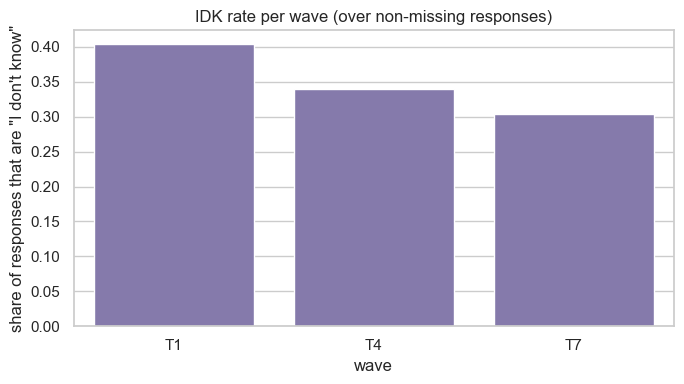

Paired Wilcoxon IDK rate T1 vs T7: W=242.5, p=0.003, rank-biserial r=0.80 (n=49 children; exploratory)
Per-child IDK propensity, T1 vs T4: Spearman rho=0.67, p=0.000 (n=48) — high rho = stable trait, ~0 = random

IDK rate per item at T7:
                    n_idk  idk_rate
item                               
GA10                   27  0.500000
EA05                   27  0.490909
GA17                   25  0.462963
LLMdesign_1            24  0.436364
UA19                   22  0.407407
GA13                   21  0.388889
GA04                   21  0.381818
CA12                   19  0.351852
EA11                   19  0.345455
DA09                   18  0.333333
PR3                    18  0.327273
CI31                   16  0.301887
PR1                    15  0.277778
microcontrollers_1     14  0.254545
GA16                   13  0.240741
sensors_2              12  0.226415
PR4                    12  0.226415
robotparts_1           12  0.222222
CI29                   11  0.203704
microc

In [4]:
# 3b.1 IDK rate per wave (over non-missing responses)
idk_wave = []
for w in WAVES:
    sub = df.loc[df['Timepoint'] == w, item_ids]
    vals = sub.values.ravel()
    vals = vals[~np.isnan(vals)]
    idk_wave.append(dict(wave=w, n_valid=len(vals), n_idk=int((vals == IDK).sum()),
                         idk_rate=float((vals == IDK).mean()) if len(vals) else np.nan))
idk_wave = pd.DataFrame(idk_wave)
print(idk_wave.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=idk_wave, x='wave', y='idk_rate', order=WAVES, color='#8172B3')
plt.ylabel('share of responses that are "I don\'t know"')
plt.title('IDK rate per wave (over non-missing responses)')
plt.tight_layout(); plt.show()

# per-child paired change T1 -> last wave (only children with data in both)
def child_idk_rate(sub):
    v = sub[item_ids].values.ravel()
    v = v[~np.isnan(v)]
    return (v == IDK).mean() if len(v) else np.nan

per_child_wave = (df.groupby(['Participant ID', 'Timepoint'])
                    .apply(child_idk_rate, include_groups=False).unstack())
w_first, w_last = WAVES[0], WAVES[-1]
paired = per_child_wave[[w_first, w_last]].dropna()
if len(paired) > 2:
    stat, p = stats.wilcoxon(paired[w_first], paired[w_last])
    r = 1 - (2 * stat) / (len(paired) * (len(paired) + 1))  # rank-biserial
    print(f'Paired Wilcoxon IDK rate {w_first} vs {w_last}: W={stat:.1f}, p={p:.3f}, '
          f'rank-biserial r={r:.2f} (n={len(paired)} children; exploratory)')

# 3b.2 Is IDK systematic? per-child propensity stable across waves?
if per_child_wave.shape[1] >= 2:
    cols = [c for c in per_child_wave.columns][:2]
    d = per_child_wave[cols].dropna()
    if len(d) > 2:
        rho, p = stats.spearmanr(d[cols[0]], d[cols[1]])
        print(f'Per-child IDK propensity, {cols[0]} vs {cols[1]}: Spearman rho={rho:.2f}, '
              f'p={p:.3f} (n={len(d)}) — high rho = stable trait, ~0 = random')

# per-item IDK at final wave (which learning points do kids *know* they don\'t know?)
item_idk_last = (acc[acc.wave == w_last]
                 .set_index('item')[['n_idk', 'idk_rate']]
                 .sort_values('idk_rate', ascending=False))
print(f'\nIDK rate per item at {w_last}:')
print(item_idk_last.to_string())

# 3b.3 IDK transitions (from §3 pattern table)
idk_pats = {k: v for k, v in pats.items() if '9' in k}
print('\nTransition patterns involving IDK (child × item):')
print(pd.Series(idk_pats).sort_values(ascending=False).to_string() if idk_pats
      else 'none observed')
n_idk_to_correct = sum(v for k, v in idk_pats.items() if k.endswith('1'))
n_idk_to_wrong = sum(v for k, v in idk_pats.items() if k.endswith('0'))
print(f'\nEnding correct after any IDK: {n_idk_to_correct}; ending wrong after any IDK: {n_idk_to_wrong}')

## 4. Linking items to curriculum elements

Each item inherits, via its **primary** concept link (fallback: partial), the concept's theme, mastery role (core/working/exposure), enacted week, and the timing delta between intended (codebook) and enacted week. Items without a validated link are reported, not dropped silently.

*Output: [will show when run]*

In [5]:
concepts = pd.read_csv(BASE / 'curriculum_concepts__validation_required.csv', keep_default_na=False)
mapping = pd.read_csv(BASE / 'concept_item_mapping__validation_required.csv', keep_default_na=False)
inventory = pd.read_csv(BASE / 'survey_items_inventory__validation_required.csv')

prim = mapping[mapping['link_strength'] == 'primary']
if not prim['item_id'].is_unique:
    prim = prim.groupby('item_id').first().reset_index()  # multiple primaries: take first, noted
sec = mapping[mapping['link_strength'] == 'partial'].groupby('item_id').first().reset_index()
link = pd.concat([prim, sec[~sec['item_id'].isin(prim['item_id'])]])

# mastery column removed 2026-09-15 pending user re-validation -> sentinel if absent
if 'mastery' not in concepts.columns:
    concepts['mastery'] = 'unclassified'
concept_cols = ['concept_id', 'theme', 'mastery', 'week_introduced']
meta = (link.merge(concepts[concept_cols],
                   on='concept_id', how='left')
            .merge(inventory[['item_id', 'codebook_week']], on='item_id', how='left'))
meta['week_introduced'] = pd.to_numeric(meta['week_introduced'], errors='coerce')
meta['timing_delta'] = meta['week_introduced'] - meta['codebook_week']

item_meta = meta.set_index('item_id')
missing_meta = [i for i in item_ids if i not in item_meta.index]
print(f'Items with curriculum metadata: {len(set(item_meta.index) & set(item_ids))} / {len(item_ids)}')
print('Items without validated concept link:', missing_meta)

# attach per-item T1/T7 accuracy and gain
for w in ['T1', 'T7']:
    item_meta[f'acc_{w}'] = acc[acc.wave == w].set_index('item')['acc']
item_meta['gain'] = item_meta['acc_T7'] - item_meta['acc_T1']
item_meta

Items with curriculum metadata: 21 / 23
Items without validated concept link: ['DA09', 'GA17']


,concept_id,link_strength,rationale,needs_validation,theme,mastery,week_introduced,codebook_week,timing_delta,acc_T1,acc_T7,gain
item_id,,,,,,,,,,,,
robotparts_1,W1_03,primary,Item shows Marty component (PCB connecting leg...,True,Hardware,unclassified,1,1.0,0.0,0.382353,0.452381,0.070028
robotparts_2,W1_03,primary,Item asks hip-motor movement; W1 slide 17: 'Hi...,True,Hardware,unclassified,1,1.0,0.0,0.472222,0.400000,-0.072222
sensors_1,W5_09,primary,Item: primary job of Marty's foot IR sensor (d...,True,Sensors,unclassified,5,5.0,0.0,0.733333,0.854167,0.120833
sensors_2,W5_06,primary,Item: what a sensor can NOT do (move a leg = a...,True,Sensors,unclassified,5,5.0,0.0,0.285714,0.390244,0.104530
microcontrollers_1,W6_02,primary,Item: main processor on Arduino Nano ESP32; W6...,True,Microcontrollers,unclassified,6,4.0,2.0,0.423077,0.463415,0.040338
microcontrollers_2,W6_01,primary,Item: role of microcontroller = run one simple...,True,Microcontrollers,unclassified,6,4.0,2.0,0.370370,0.500000,0.129630
AI_DA09,W2_01,primary,Item: AI differs from previous IT via learning...,True,AI,unclassified,2,NaN,NaN,NaN,NaN,NaN
CA12,W2_02,primary,Item: which example is NOT AI (big-data storag...,True,AI,unclassified,2,2.0,0.0,0.513514,0.485714,-0.027799
CI29,W2_04,primary,Item: face-to-Van-Gogh app = generation; W2 sl...,True,ML,unclassified,2,2.0,0.0,0.697674,0.720930,0.023256


## 5. Do outcomes correlate with curriculum elements?

- **Theme / mastery / week taught:** group differences in T7 accuracy and T7−T1 gain.
- **Timing mismatch:** Spearman correlation between |intended−enacted week| and gain (did items taught in a different week than planned fare worse?).
- **Recency:** Spearman correlation between week introduced and T7 accuracy.

Small N of items (≤23) → treat p-values as exploratory; report effect sizes.

*Output: [will show when run]*

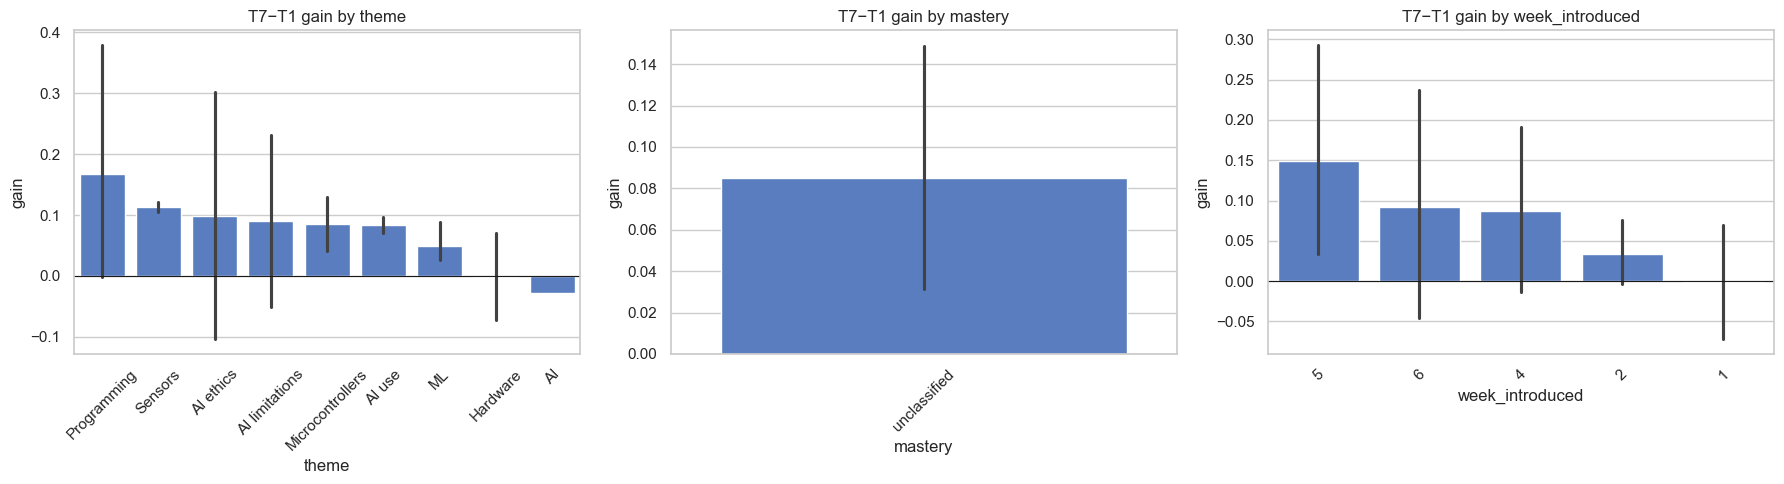

Kruskal-Wallis gain ~ theme: H=3.23, p=0.863 (groups: 8)
Spearman |timing delta| vs gain: rho=0.24, p=0.286 (n=21 items)
Spearman week introduced vs T7 accuracy (recency): rho=0.16, p=0.498 (n=21)


In [6]:
m = item_meta.loc[item_meta.index.isin(item_ids)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['theme', 'mastery', 'week_introduced']):
    d = m.dropna(subset=['gain'])
    order = d.groupby(col)['gain'].mean().sort_values(ascending=False).index
    sns.barplot(data=d, x=col, y='gain', order=order, ax=ax, errorbar=('ci', 95))
    ax.axhline(0, color='k', lw=0.8); ax.set_title(f'T7−T1 gain by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

for col in ['theme', 'mastery']:
    groups = [g['gain'].dropna() for _, g in m.groupby(col) if len(g['gain'].dropna()) > 1]
    if len(groups) > 1:
        H, p = stats.kruskal(*groups)
        print(f'Kruskal-Wallis gain ~ {col}: H={H:.2f}, p={p:.3f} (groups: {len(groups)})')

d = m.dropna(subset=['timing_delta', 'gain'])
if len(d) > 2:
    rho, p = stats.spearmanr(d['timing_delta'].abs(), d['gain'])
    print(f'Spearman |timing delta| vs gain: rho={rho:.2f}, p={p:.3f} (n={len(d)} items)')
d = m.dropna(subset=['week_introduced', 'acc_T7'])
if len(d) > 2:
    rho, p = stats.spearmanr(d['week_introduced'], d['acc_T7'])
    print(f'Spearman week introduced vs T7 accuracy (recency): rho={rho:.2f}, p={p:.3f} (n={len(d)})')

## 6. Self-report vs. performance (MAILS × knowledge)

Literature predicts weak or even negative subjective–objective correspondence in children (see `Literature/literature_review__validation_required.md` §4). Per wave: Spearman correlation between a child's MAILS mean and their knowledge accuracy.

*Output: [will show when run]*

T1: Spearman MAILS × knowledge-accuracy: rho=-0.15, p=0.246 (n=58)
T4: Spearman MAILS × knowledge-accuracy: rho=-0.11, p=0.433 (n=51)
T7: Spearman MAILS × knowledge-accuracy: rho=-0.13, p=0.355 (n=55)


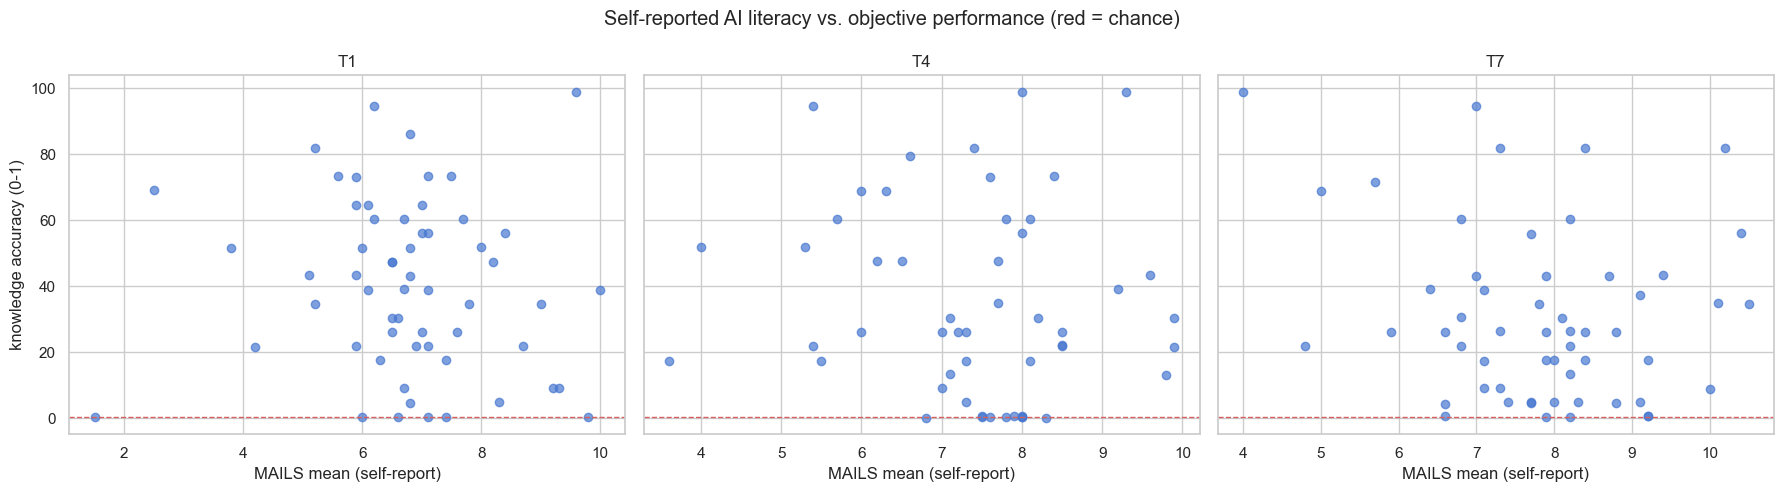

In [7]:
mails_cols = [c for c in df.columns if c.startswith('MAILS_')]
for c in mails_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').replace([99, 999], np.nan)

for w in WAVES:
    sub = df[df['Timepoint'] == w]
    k_acc = sub[item_ids].mean(axis=1)
    m_mean = sub[mails_cols].mean(axis=1)
    ok = k_acc.notna() & m_mean.notna()
    if ok.sum() > 2:
        rho, p = stats.spearmanr(m_mean[ok], k_acc[ok])
        print(f'{w}: Spearman MAILS × knowledge-accuracy: rho={rho:.2f}, p={p:.3f} (n={int(ok.sum())})')

fig, axes = plt.subplots(1, len(WAVES), figsize=(6 * len(WAVES), 5), sharey=True)
for ax, w in zip(axes, WAVES):
    sub = df[df['Timepoint'] == w]
    ax.scatter(sub[mails_cols].mean(axis=1), sub[item_ids].mean(axis=1), alpha=0.7)
    ax.axhline(CHANCE, color='r', ls='--', lw=1)
    ax.set_title(w); ax.set_xlabel('MAILS mean (self-report)')
axes[0].set_ylabel('knowledge accuracy (0-1)')
plt.suptitle('Self-reported AI literacy vs. objective performance (red = chance)')
plt.tight_layout(); plt.show()

## 8. Build vs Control (same battery, different enactment)

Control is in `combined_df-Table 1.csv`. Hypothesis checks (illustrative):
- Did **both** groups move above their own T1?
- Robot parts: Build should outperform Control (`W1_03` was build-only).
- GA10 / prompting: experimental W7 GPT sessions ran; control technical failure — predict GA10 gain mainly in experimental.
- Pedagogy is **not** 'hands-on ⇒ gain': microcontrollers were handled and still mixed; EA11 (environmental cost) was lecture and rose in **both** groups.

*Output: [will show when run]*

In [ ]:
def answered_acc(frame, cols):
    v = frame[cols].to_numpy(dtype=float).ravel()
    v = v[~np.isnan(v)]
    ans = v[v != IDK]
    if len(ans) == 0:
        return np.nan, 0
    return float((ans == 1).mean()), int(len(ans))

print('Pooled accuracy by group x wave (0/1 only):')
for g in GROUPS:
    for w in WAVES:
        sub = df[(df['Experimental_group'] == g) & (df['Timepoint'] == w)]
        a, n = answered_acc(sub, item_ids)
        print(f'  {g:14s} {w}: acc={a:.3f} (n_answered={n}, n_kids={sub["Participant ID"].nunique()})')

def child_acc(sub):
    a, n = answered_acc(sub, item_ids)
    return a

ch = (df.groupby(['Participant ID', 'Experimental_group', 'Timepoint'])
        .apply(child_acc, include_groups=False).unstack())
print('\nPaired child T1 vs T7:')
gains = {}
for g in GROUPS:
    d = ch.xs(g, level=1)[['T1', 'T7']].dropna()
    if len(d) > 2:
        stat, p = stats.wilcoxon(d['T1'], d['T7'])
        gains[g] = d['T7'] - d['T1']
        print(f'  {g}: n={len(d)} T1={d.T1.mean():.3f} T7={d.T7.mean():.3f} '
              f'gain={gains[g].mean():.3f} Wilcoxon p={p:.3f} (exploratory)')
if len(gains) == 2:
    u, p = stats.mannwhitneyu(gains['experimental'], gains['control'])
    print(f'Mann-Whitney gain experimental vs control: U={u:.1f} p={p:.3f} (exploratory)')

rows = []
for item in item_ids:
    rec = {'item': item}
    for g, tag in [('experimental', 'e'), ('control', 'c')]:
        for w in ['T1', 'T7']:
            v = df.loc[(df.Experimental_group == g) & (df.Timepoint == w), item].dropna()
            ans = v[v != IDK]
            rec[f'{tag}_{w}'] = float((ans == 1).mean()) if len(ans) else np.nan
        rec[f'{tag}_gain'] = rec[f'{tag}_T7'] - rec[f'{tag}_T1']
    rows.append(rec)
gtab = pd.DataFrame(rows)
print('\nPer-item T1/T7/gain by group:')
print(gtab.round(2).to_string(index=False))
print('\nRobot-parts (predict Build > Control at T7):')
print(gtab[gtab.item.str.startswith('robot')].round(3).to_string(index=False))

Pooled accuracy by group x wave (0/1 only):
  experimental   T1: acc=0.384 (n_answered=424, n_kids=30)
  experimental   T4: acc=0.433 (n_answered=434, n_kids=29)
  experimental   T7: acc=0.462 (n_answered=435, n_kids=27)
  control        T1: acc=0.435 (n_answered=372, n_kids=28)
  control        T4: acc=0.456 (n_answered=329, n_kids=22)
  control        T7: acc=0.521 (n_answered=432, n_kids=26)

Paired child T1 vs T7:
  experimental: n=26 T1=0.384 T7=0.467 gain=0.083 Wilcoxon p=0.013 (exploratory)
  control: n=21 T1=0.463 T7=0.516 gain=0.052 Wilcoxon p=0.562 (exploratory)
Mann-Whitney gain experimental vs control: U=318.0 p=0.341 (exploratory)

Per-item T1/T7/gain by group:
              item  e_T1  e_T7  e_gain  c_T1  c_T7  c_gain
      robotparts_1  0.33  0.52    0.19  0.44  0.35   -0.08
      robotparts_2  0.41  0.21   -0.20  0.57  0.62    0.05
         sensors_1  0.74  0.86    0.12  0.72  0.85    0.13
         sensors_2  0.32  0.38    0.06  0.25  0.40    0.15
microcontrollers_1  0.

## 9. IDK exits per item (the calibration leak)

Among child×item sequences that contain any IDK, where do they **end** at T7? Rank items by IDK→wrong. High `p(wrong | exit)` + stay-IDK = teaching failed to convert uncertainty into knowledge (or the item is a trap).

*Output: [will show when run]*

In [ ]:
def seq_states(vals):
    out = []
    for x in vals:
        if pd.isna(x): out.append('?')
        elif x == IDK: out.append('9')
        elif x == 1: out.append('1')
        else: out.append('0')
    return ''.join(out)

rows = []
for item in item_ids:
    w = df.pivot_table(index=['Participant ID', 'Experimental_group'],
                       columns='Timepoint', values=item, aggfunc='first')
    for (pid, g), row in w.iterrows():
        seq = seq_states([row.get('T1'), row.get('T4'), row.get('T7')])
        if '9' in seq.replace('?', ''):
            rows.append(dict(item=item, group=g, seq=seq, end=seq[-1]))
idf = pd.DataFrame(rows)
print(f'Sequences with any IDK: {len(idf)}; '
      f'end correct={(idf.end=="1").sum()}; end wrong={(idf.end=="0").sum()}; '
      f'stay IDK={(idf.end=="9").sum()}')
sm = []
for item, d in idf.groupby('item'):
    e1 = int((d.end == '1').sum()); e0 = int((d.end == '0').sum()); e9 = int((d.end == '9').sum())
    ex = e1 + e0
    sm.append(dict(item=item, n=len(d), end_correct=e1, end_wrong=e0, stay_idk=e9,
                   p_wrong_if_exit=(e0 / ex if ex else np.nan)))
sm = pd.DataFrame(sm).sort_values(['end_wrong', 'p_wrong_if_exit'], ascending=False)
print('\nItems ranked by IDK→wrong count:')
print(sm.round(2).to_string(index=False))
print('\nWorst conversion (p_wrong_if_exit among items with >=8 exits):')
print(sm[sm.end_correct + sm.end_wrong >= 8].sort_values('p_wrong_if_exit', ascending=False).head(8).round(2).to_string(index=False))

Sequences with any IDK: 802; end correct=140; end wrong=180; stay IDK=362

Items ranked by IDK→wrong count:
              item  n  end_correct  end_wrong  stay_idk  p_wrong_if_exit
microcontrollers_2 41           12         16         9             0.57
      robotparts_2 33            7         14         8             0.67
              GA04 40            2         12        19             0.86
      robotparts_1 32            5         11        12             0.69
              DA09 37            4         10        17             0.71
              GA17 44            4         10        24             0.71
              UA19 41            4         10        21             0.71
microcontrollers_1 40           11         10        13             0.48
               PR4 25            1          8        12             0.89
              EA11 36            4          8        18             0.67
              GA13 41            6          8        21             0.57
         sensors

## 10. Engagement (weekly IMI) × concept load / pedagogy

Join weekly IMI (enjoyment, competence, pressure, usefulness) to concepts-introduced-that-week and ICAP mix. Hypothesis (user): inverted-U / negative relation between concept load and satisfaction. Exploratory only (n=7 weeks).

*Output: [will show when run]*

Weekly IMI means by group:
--- experimental
  T1 n=29 enjoy=4.45 comp=4.33 press=2.10 useful=4.03
  T2 n=25 enjoy=4.08 comp=4.00 press=2.24 useful=3.98
  T3 n=27 enjoy=4.35 comp=4.20 press=1.85 useful=3.96
  T4 n=30 enjoy=4.12 comp=4.02 press=2.47 useful=3.87
  T5 n=29 enjoy=3.71 comp=3.55 press=2.11 useful=3.54
  T6 n=29 enjoy=4.07 comp=3.84 press=2.21 useful=3.82
  T7 n=26 enjoy=3.85 comp=3.65 press=2.12 useful=3.71
--- control
  T1 n=28 enjoy=4.05 comp=4.04 press=1.54 useful=3.14
  T2 n=21 enjoy=3.74 comp=4.26 press=1.86 useful=3.43
  T3 n=22 enjoy=4.20 comp=4.25 press=1.95 useful=3.16
  T4 n=23 enjoy=3.17 comp=3.89 press=1.83 useful=2.54
  T5 n=26 enjoy=3.38 comp=3.85 press=2.04 useful=3.04
  T6 n=27 enjoy=3.76 comp=3.94 press=2.00 useful=3.44
  T7 n=28 enjoy=3.70 comp=3.79 press=1.86 useful=3.41

Week-level enjoy vs n_concepts:
      enjoy  pressure  n_concepts
week                             
1      4.25      1.82           3
2      3.92      2.07          10
3      4.29      1.

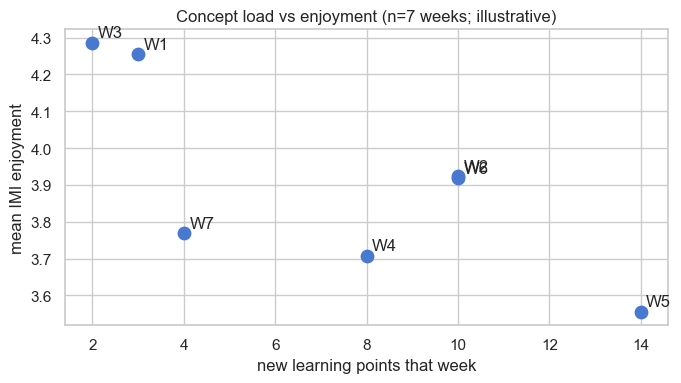

In [10]:
eng = pd.read_csv(BASE / 'Data/BuildBots_engagement_children_cntrl&exp_merged_T1-T7_EN.csv',
                  encoding='latin-1')
imi = [f'IntrinsicMotivation_{i}' for i in range(1, 9)]
for c in imi:
    eng[c] = pd.to_numeric(eng[c], errors='coerce')
eng['enjoy'] = eng[['IntrinsicMotivation_1', 'IntrinsicMotivation_2']].mean(axis=1)
eng['competence'] = eng[['IntrinsicMotivation_3', 'IntrinsicMotivation_4']].mean(axis=1)
eng['pressure'] = eng['IntrinsicMotivation_6']
eng['useful'] = eng[['IntrinsicMotivation_7', 'IntrinsicMotivation_8']].mean(axis=1)

print('Weekly IMI means by group:')
for g in ['experimental', 'control']:
    print('---', g)
    for w in [f'T{i}' for i in range(1, 8)]:
        sub = eng[(eng.Experimental_group == g) & (eng.Timepoint == w)]
        if not len(sub):
            continue
        print(f'  {w} n={len(sub)} enjoy={sub.enjoy.mean():.2f} '
              f'comp={sub.competence.mean():.2f} press={sub.pressure.mean():.2f} '
              f'useful={sub.useful.mean():.2f}')

n_by_week = concepts.groupby('week_introduced').size()
eng['week'] = eng['Timepoint'].map({f'T{i}': i for i in range(1, 8)})
eng['n_concepts'] = eng['week'].map(n_by_week)
wk = (eng.groupby('week')
        .agg(enjoy=('enjoy', 'mean'), pressure=('pressure', 'mean'),
             n_concepts=('n_concepts', 'first')).dropna())
print('\nWeek-level enjoy vs n_concepts:')
print(wk.round(2))
if len(wk) > 3:
    rho, p = stats.spearmanr(wk.n_concepts, wk.enjoy)
    print(f'Spearman n_concepts vs enjoy: rho={rho:.2f} p={p:.3f} (n_weeks={len(wk)}; exploratory)')
    rho, p = stats.spearmanr(wk.n_concepts, wk.pressure)
    print(f'Spearman n_concepts vs pressure: rho={rho:.2f} p={p:.3f}')

ped = pd.read_csv(BASE / 'curriculum_concept_pedagogy__validation_required.csv')
icap = ped.merge(concepts[['concept_id', 'week_introduced']], on='concept_id', how='left')
mix = icap.groupby(['week_introduced', 'icap_level']).size().unstack(fill_value=0)
print('\nICAP mix per week:\n', mix)
passive_share = mix.get('passive', 0) / mix.sum(axis=1)
wk = wk.copy()
wk['passive_share'] = wk.index.map(passive_share)
d = wk.dropna()
if len(d) > 3:
    rho, p = stats.spearmanr(d.passive_share, d.enjoy)
    print(f'Spearman passive_share vs enjoy: rho={rho:.2f} p={p:.3f} (exploratory)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(wk.n_concepts, wk.enjoy, s=80)
for i, r in wk.iterrows():
    ax.annotate(f'W{int(i)}', (r.n_concepts, r.enjoy), xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('new learning points that week'); ax.set_ylabel('mean IMI enjoyment')
ax.set_title('Concept load vs enjoyment (n=7 weeks; illustrative)')
plt.tight_layout(); plt.show()

## 11. Timing-aware waves — when was each item taught?

T4 sits mid-intervention, so the relevant contrast depends on when the concept was taught (user spec, 2026-09-17):

- **Taught W1–4** (not repeated after T4): T1→T4 (immediate), T1→T7 (long-term retention)
- **Taught W5–7**: T4→T7 (immediate — T4 is a genuine pre-test), T1→T7 (overall)
- **Taught W1–4, repeated W5–7**: T1→T7 only (spaced exposure; immediate effect not isolable)

Item→week lookup uses **primary** concept links only; `AI_DA09` is normalized to `DA09` (data-file rename).

*Output: [will show when run]*

In [ ]:
import re as _re
prim = (mapping[mapping['link_strength'] == 'primary']
            .drop_duplicates('item_id')
            .merge(concepts[['concept_id', 'week_introduced', 'weeks_revisited']], on='concept_id', how='left'))
prim['item_id'] = prim['item_id'].str.replace('AI_DA09', 'DA09', regex=False)  # data file renames AI_DA09 -> DA09
prim['week_introduced'] = pd.to_numeric(prim['week_introduced'], errors='coerce')
prim['revisit_late'] = prim['weeks_revisited'].apply(lambda s: any(int(x) >= 5 for x in _re.findall(r'\d+', str(s))))
item_week = dict(zip(prim['item_id'], prim['week_introduced']))
item_revis = dict(zip(prim['item_id'], prim['revisit_late']))

def timing_class(item):
    w = item_week.get(item, np.nan)
    if pd.isna(w):
        return 'no primary link'
    if w <= 4:
        return 'W1-4 + repeated W5-7' if item_revis.get(item) else 'W1-4'
    return 'W5-7'

def item_acc(frame, item):
    v = frame[item].dropna()
    ans = v[v != IDK]
    return float((ans == 1).mean()) if len(ans) else np.nan

rows = []
for item in item_ids:
    rec = {'item': item, 'taught_week': item_week.get(item, np.nan), 'timing': timing_class(item)}
    for w in WAVES:
        rec[w] = item_acc(df[df['Timepoint'] == w], item)
    rows.append(rec)
ttab = pd.DataFrame(rows)
print(ttab.round(2).to_string(index=False))

print()
print('Relevant contrasts per timing class (item-mean accuracy):')
for tc, contrasts in [('W1-4', [('T1', 'T4'), ('T1', 'T7')]),
                      ('W5-7', [('T4', 'T7'), ('T1', 'T7')]),
                      ('W1-4 + repeated W5-7', [('T1', 'T7')])]:
    sub = ttab[ttab.timing == tc]
    if not len(sub):
        print(f'{tc}: n=0 — no early concept was repeated late in the enacted curriculum')
        continue
    print(f'{tc}  (n={len(sub)} items)')
    for pre, post in contrasts:
        print(f'   {pre}={sub[pre].mean():.2f} -> {post}={sub[post].mean():.2f}  gain={sub[post].mean() - sub[pre].mean():+.2f}')

              item  taught_week        timing   T1   T4   T7
      robotparts_1          1.0 W1-3 (T1 pre) 0.38 0.55 0.45
      robotparts_2          1.0 W1-3 (T1 pre) 0.47 0.38 0.40
         sensors_1          5.0 W5-7 (T4 pre) 0.73 0.78 0.85
         sensors_2          5.0 W5-7 (T4 pre) 0.29 0.37 0.39
microcontrollers_1          6.0 W5-7 (T4 pre) 0.42 0.65 0.46
microcontrollers_2          6.0 W5-7 (T4 pre) 0.37 0.38 0.50
              DA09          NaN      unmapped 0.21 0.41 0.36
              CA12          2.0 W1-3 (T1 pre) 0.51 0.38 0.49
              CI29          2.0 W1-3 (T1 pre) 0.70 0.56 0.72
              CI31          2.0 W1-3 (T1 pre) 0.35 0.54 0.46
              UA19          2.0 W1-3 (T1 pre) 0.19 0.36 0.22
              GA10          4.0   W4 (T4 mid) 0.42 0.46 0.52
       LLMdesign_1          4.0   W4 (T4 mid) 0.35 0.26 0.42
              GA13          2.0 W1-3 (T1 pre) 0.45 0.59 0.48
              EA05          4.0   W4 (T4 mid) 0.48 0.40 0.71
              GA04      

## 12. What kind of assessment did kids fail? — Bloom levels + wording audit

Bloom level per item (conservative, from stem). Plus a wording audit: **negative stems** (NOT / worse / does-not-cause) bias younger and weaker readers (Marsh, 1986; Haladyna et al., 2002, guideline 17; Borgers et al., 2000). A child who misses the negation picks the *best-looking* option and is scored wrong — the item then measures reading attention, not knowledge. For `LLMdesign_1` we can test this directly: options a and d are *good* prompts, so the negation-misreader attractors are known.

*Output: [will show when run]*

In [12]:
BLOOM = {
    'robotparts_1': 'Remember', 'robotparts_2': 'Remember', 'microcontrollers_1': 'Remember', 'GA10': 'Remember',
    'sensors_1': 'Understand', 'sensors_2': 'Understand', 'microcontrollers_2': 'Understand', 'DA09': 'Understand',
    'UA19': 'Understand', 'GA13': 'Understand', 'GA04': 'Understand', 'PR1': 'Understand', 'EA11': 'Understand',
    'CI29': 'Apply', 'CI31': 'Apply', 'PR2': 'Apply', 'PR3': 'Apply', 'PR4': 'Apply',
    'CA12': 'Analyze', 'EA05': 'Analyze', 'GA16': 'Evaluate', 'GA17': 'unknown (stem missing)',
}
btab = ttab.copy()
btab['bloom'] = btab['item'].map(BLOOM)
print('Accuracy by Bloom level (item means):')
for lev in ['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'unknown (stem missing)']:
    sub = btab[btab.bloom == lev]
    if len(sub):
        print(f'  {lev:22s} n={len(sub)}  T1={sub.T1.mean():.2f} T4={sub.T4.mean():.2f} T7={sub.T7.mean():.2f} gain={sub.T7.mean() - sub.T1.mean():+.2f}')

NEG = ['sensors_2', 'CA12', 'LLMdesign_1', 'GA04']
POS = [i for i in item_ids if i not in NEG]
def pool(sub, items):
    v = sub[items].to_numpy(dtype=float).ravel()
    v = v[~np.isnan(v)]
    ans = v[v != IDK]
    return float((ans == 1).mean()) if len(ans) else np.nan
print()
print('Negative-stem vs positive-stem items (pooled accuracy):')
for w in WAVES:
    sub = df[df['Timepoint'] == w]
    print(f'  {w}: negative (n=4) acc={pool(sub, NEG):.3f}   positive (n={len(POS)}) acc={pool(sub, POS):.3f}')

# LLMdesign_1 misreader attractors: options a (1) and d (4) are the GOOD prompts
raw = pd.read_csv(BASE / 'Data/combineddf_T1_T4_T7/combined_df-Table 1.csv', sep=';')
raw = raw[raw['Experimental_group'].isin(['experimental', 'control'])]
raw_llm = pd.to_numeric(raw['LLMdesign_1'], errors='coerce')
print()
print('LLMdesign_1: share choosing a GOOD prompt (a or d) as the worse one (misread signature):')
for w in WAVES:
    l = raw_llm[raw['Timepoint'] == w].dropna()
    print(f'  {w}: {float(((l == 1) | (l == 4)).mean()):.0%} (n={len(l)})')

print()
print('GA04 extra flag: the stem defines hallucination as nonsensical / grammatically incorrect text')
print('(surface-error definition) while learning point W4_04 teaches plausible-but-false + always verify;')
print('the item premise contradicts the taught learning point AND is negatively worded.')

Accuracy by Bloom level (item means):
  Remember               n=4  T1=0.42 T4=0.51 T7=0.46 gain=+0.03
  Understand             n=9  T1=0.35 T4=0.43 T7=0.47 gain=+0.11
  Apply                  n=5  T1=0.45 T4=0.52 T7=0.58 gain=+0.12
  Analyze                n=2  T1=0.50 T4=0.39 T7=0.60 gain=+0.10
  Evaluate               n=1  T1=0.35 T4=0.24 T7=0.24 gain=-0.10
  unknown (stem missing) n=1  T1=0.45 T4=0.27 T7=0.38 gain=-0.08

Negative-stem vs positive-stem items (pooled accuracy):
  T1: negative (n=4) acc=0.371   positive (n=19) acc=0.417
  T4: negative (n=4) acc=0.313   positive (n=19) acc=0.471
  T7: negative (n=4) acc=0.397   positive (n=19) acc=0.510

LLMdesign_1: share choosing a GOOD prompt (a or d) as the worse one (misread signature):
  T1: 36% (n=58)
  T4: 28% (n=50)
  T7: 27% (n=55)

GA04 extra flag: the stem defines hallucination as nonsensical / grammatically incorrect text
(surface-error definition) while learning point W4_04 teaches plausible-but-false + always verify;
the

## 7. Findings (fill in after running; also §§8–10)

- Chance level, item level: [will show when run]
- Build vs Control (§8): [will show]
- IDK→wrong by item (§9): [will show]
- Engagement × concept load / ICAP (§10): [will show]
- MAILS × performance: [will show when run]

## Limitations

- **Stats are illustrative, not inferential claims:** N is too small to generalize; tests demonstrate *which analyses* a learning-point-level representation enables.
- Battery limits: 23 items, 4-option MC + IDK, mixed provenance — vs AI-CI's 8–22 items/construct (Zhang et al., 2025).
- `LLMdesign_1` option-5→IDK is an assumption (see §1). `GA17` still has no recoverable stem.
- Combined file now includes **control**; T8 delayed post still pending.
- Week-level engagement correlations have n=7 — report as illustration only.
